In [ ]:
"""
LangGraph workflow for the Fraud Investigation Copilot.
"""

import uuid
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from langgraph.types import interrupt, Command
from langsmith import traceable
from state import InvestigationState
from scoring import Transaction, score_transaction
from history_store import (
    get_account_history,
    update_score,
    update_investigation_status,
    record_investigator_feedback,
)
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from knowledge_base import search_fraud_patterns
from tools import get_account_history as get_account_history_tool
from langgraph.prebuilt import ToolNode
from langchain.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
from typing import Literal
from history_store import get_account_feedback
from pathlib import Path

load_dotenv()

model = ChatGoogleGenerativeAI(
    model="gemma-4-26b-a4b-it",
    temperature=0.1,
    max_output_tokens=8192,
)

# FIX 2: check_transaction_fraud removed — scoring is deterministic,
# already ran in score_node, and shouldn't be re-callable mid-investigation.
tools = [get_account_history_tool, search_fraud_patterns]

SYSTEM_PROMPT = """
You are a Senior Fraud Investigation Copilot. Your objective is to investigate financial transactions that have been flagged by our XGBoost machine learning model.

You have access to the flagged transaction details and its initial fraud score. You must act as a detective to determine WHY the transaction was flagged and whether it constitutes genuine fraud or a false positive.

### Available Tools:
1. `get_account_history`: Use this to pull the last 50 transactions of either the sender or the receiver.
   - Call this if the ML model indicates "receiver_degree" or "velocity_score" as top contributing features.
   - Look for signs of mule accounts (new accounts receiving many transfers) or account takeovers (sudden spikes in spending).
2. `search_fraud_patterns`: Use this to query the vector database of known fraud typologies.
   - Call this if the transaction pattern is ambiguous or if you need precedent for specific merchant categories or geographic anomalies.

### Investigation Protocol:
1. Analyze the Context: Review the transaction details and the specific features that drove the high fraud probability score.
2. Gather Evidence: You MUST use the available tools to gather more context. Do not guess. If the sender's history wasn't enough to clear the flag, check the receiver's history.
3. Synthesize: Compare the transaction against the retrieved history and known fraud patterns.
4. Formulate a Conclusion: Determine your findings.
"""

llm_with_tools = model.bind_tools(tools)


class InvestigationReport(BaseModel):
    detailed_markdown_report: str = Field(
        description="A highly detailed, professional investigation report formatted in Markdown."
    )
    recommendation: Literal["clear", "investigate_further", "likely_fraud"] = Field(
        description="The final definitive recommendation for routing."
    )


report_llm = model.with_structured_output(InvestigationReport)

REPORT_PROMPT = """
You are a Senior Fraud Investigation Analyst. You have completed the evidence-gathering phase for a flagged transaction.

Review the preceding conversation history containing the initial transaction details and raw tool outputs. Synthesize this evidence into a final, structured Investigation Report.

CRITICAL CONSTRAINTS:
1. STRICT CONCISENESS: Your detailed Markdown report must be highly analytical but strictly under 300 words.
2. STRUCTURE: Use Markdown headers (e.g., ### Executive Summary, ### Anomaly Analysis).
3. ZERO HALLUCINATION: Ground your analysis STRICTLY in the provided tool outputs. If a tool returned "No prior history", explicitly state this as a risk factor.
4. NO FURTHER ACTIONS: Do not attempt to use any more tools.
5. DEFINITIVE CONCLUSION: Provide a clear recommendation (clear, investigate_further, or likely_fraud).
"""

DB_PATH = Path("/home/arjunverma/Coding New/Fraud Investigation copilot/db/checkpoints.db")
DB_PATH.parent.mkdir(parents=True, exist_ok=True)

@traceable
def score_node(state: InvestigationState) -> InvestigationState:
    txn_dict = state["transaction"]
    txn = Transaction(**txn_dict)

    sender_history = get_account_history(txn.sender_account, as_sender=True)
    fraud_score = score_transaction(txn, sender_history)

    update_score(
        transaction_id=txn_dict["transaction_id"],
        fraud_probability=fraud_score["fraud_probability"],
        is_flagged=fraud_score["is_flagged"],
    )

    return {**state, "fraud_score": fraud_score}


@traceable
def route_after_scoring(state: InvestigationState) -> str:
    return "investigate_node" if state["fraud_score"]["is_flagged"] else END




@traceable
def investigate_node(state: InvestigationState) -> InvestigationState:
    transaction = state["transaction"]
    fraud_score = state["fraud_score"]

    if not state["messages"]:
        sender_feedback = get_account_feedback(transaction["sender_account"])
        receiver_feedback = get_account_feedback(transaction["receiver_account"])

        feedback_context = ""
        if sender_feedback or receiver_feedback:
            feedback_context = (
                f"\n\nRelevant history of past human investigator decisions:\n"
                f"Sender ({transaction['sender_account']}): {sender_feedback}\n"
                f"Receiver ({transaction['receiver_account']}): {receiver_feedback}\n"
                f"Weigh this prior context appropriately — e.g. an account "
                f"repeatedly cleared by humans warrants more benefit of the "
                f"doubt than one previously confirmed as fraud."
            )

        conversation = [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(
                content=(
                    f"Investigate the following flagged transaction: {transaction} "
                    f"with fraud score: {fraud_score}{feedback_context}"
                )
            ),
        ]
        # Also populate the dedicated state field, per Task 4's original
        # design intent — not just buried in the prompt string.
        account_feedback_history = sender_feedback + receiver_feedback
    else:
        conversation = state["messages"]
        account_feedback_history = state["account_feedback_history"]

    response = llm_with_tools.invoke(conversation)

    return {
        **state,
        "messages": [response],
        "iteration_count": state["iteration_count"] + 1,
        "account_feedback_history": account_feedback_history,
    }


@traceable
def route_after_investigate(state: InvestigationState) -> str:
    if state["iteration_count"] >= 4:
        return "report_node"
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"
    return "report_node"


@traceable
def report_node(state: InvestigationState) -> InvestigationState:
    conversation = state["messages"]

    # FIX 4: drop a dangling tool call (cap fired mid-request) so the
    # conversation handed to report_llm is always well-formed.
    if getattr(conversation[-1], "tool_calls", None):
        conversation = conversation[:-1]

    # FIX 3: actually inject REPORT_PROMPT so the model knows to
    # conclude, not continue investigating.
    conversation = conversation + [HumanMessage(content=REPORT_PROMPT)]

    report_response = report_llm.invoke(conversation)

    # FIX 1: write into the correct, schema-declared fields.
    return {
        **state,
        "investigation_report": report_response.detailed_markdown_report,
        "recommendation": report_response.recommendation,
    }


tool_node = ToolNode(tools)


# ---------------------------------------------------------------------
# Task 7: HITL gate
# ---------------------------------------------------------------------
@traceable
def human_review_node(state: InvestigationState) -> InvestigationState:
    decision_payload = interrupt(
        {
            "report": state["investigation_report"],
            "recommendation": state["recommendation"],
            "fraud_score": state["fraud_score"],
            "transaction": state["transaction"],
        }
    )
    decision = decision_payload.get("decision")
    notes = decision_payload.get("notes", "")

    txn_id = state["transaction"]["transaction_id"]
    account_id = state["transaction"]["sender_account"]

    status_map = {
        "approve": "cleared",
        "reject": "confirmed_fraud",
        "need_more_info": "pending",
    }
    update_investigation_status(txn_id, status_map.get(decision, "pending"))

    if decision in ("approve", "reject"):
        record_investigator_feedback(txn_id, account_id, decision, notes)

    new_messages = state["messages"]
    if decision == "need_more_info":
        # Tell the LLM explicitly why it's continuing, so the next
        # investigate_node call reasons about the human's actual concern
        # instead of just repeating its prior conclusion.
        followup_note = (
            f"A human reviewer has requested more information before making "
            f"a final decision on this transaction. Reviewer's note: "
            f"\"{notes or 'No specific note provided — re-examine the evidence more thoroughly.'}\" "
            f"Continue your investigation, using additional tool calls if needed, "
            f"and address this specific concern in your next report."
        )
        new_messages = new_messages + [HumanMessage(content=followup_note)]

    return {
        **state,
        "human_decision": decision,
        "human_notes": notes,
        "messages": new_messages,
    }

# ---------------------------------------------------------------------
# Task 8: iterative loop
# ---------------------------------------------------------------------
@traceable
def route_after_human(state: InvestigationState) -> str:
    if state["human_decision"] == "need_more_info" and state["iteration_count"] < 6:
        # cap raised slightly here (6) since this is a SEPARATE cap from
        # the initial investigation loop — a human asking for more info
        # deserves a bit more room than the LLM's own unsupervised loop.
        return "investigate_node"
    return END




/home/arjunverma/miniconda3/envs/common-env/lib/python3.12/pickle.py:1760: UserWarning: [22:54:21] WARNING: /__w/xgboost/xgboost/src/gbm/gbtree.cc:443: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
/home/arjunverma/miniconda3/envs/common-env/lib/python3.12/pickle.py:1760: UserWarning: [22:54:21] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  setstate(state)
/home/arjunverma/miniconda3/envs/common-env/lib/python3.12/pickle.py:1760: UserWarning: [22:54:21] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  setstate(state)
/home/arjunverma/miniconda3/envs/common-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/arjunverma

Database for RAG Initialized.


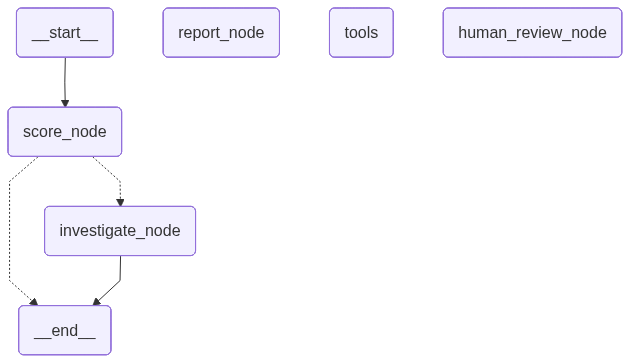

In [2]:
# ---------------------------------------------------------------------
# Build the graph
# ---------------------------------------------------------------------
def build_graph():
    builder = StateGraph(InvestigationState)

    builder.add_node("score_node", score_node)
    builder.add_node("investigate_node", investigate_node)
    builder.add_node("report_node", report_node)
    builder.add_node("tools", tool_node)
    builder.add_node("human_review_node", human_review_node)

    builder.add_edge(START, "score_node")
    builder.add_conditional_edges(
        "score_node",
        route_after_scoring,
        {"investigate_node": "investigate_node", END: END},
    )
    builder.add_conditional_edges("investigate_node", route_after_investigate)
    builder.add_edge("tools", "investigate_node")
    builder.add_edge("report_node", "human_review_node")
    builder.add_conditional_edges(
        "human_review_node",
        route_after_human,
        {"investigate_node": "investigate_node", END: END},
    )


    conn = sqlite3.connect(DB_PATH, check_same_thread=False)
    checkpointer = SqliteSaver(conn)
    return builder.compile(checkpointer=checkpointer)


graph = build_graph()
graph

In [ ]:


# ---------------------------------------------------------------------
# Manual test harness — run this file directly to sanity-check the
# score_node + branch in isolation, per the recommended build order.
# ---------------------------------------------------------------------
if __name__ == "__main__":
    sample_transaction = {
        "transaction_id": str(uuid.uuid4()),
        "sender_account": "ACC1001",
        "receiver_account": "ACC499875",
        "amount": 50.8,
        "timestamp": "2026-07-13T02:15:00",
        "merchant_category": "online",
        "transaction_type": "withdrawal",
        "spending_deviation_score": 3.2,
        "velocity_score": 55.0,
        "geo_anomaly_score": 1.8,
        "ip_address": "10.0.0.1",
        "device_used": "mobile",
        "location": "Tokyo",
        "payment_channel": "wire_transfer",
        "device_hash": "abc123",
        "time_since_last_transaction": -4435.60446271083
    }

    initial_state: InvestigationState = {
        "transaction": sample_transaction,
        "fraud_score": {},
        "account_checks": [],
        "retrieved_patterns": [],
        "account_feedback_history": [],
        "investigation_report": "",
        "human_decision": None,
        "human_notes": None,
        "messages": [],
        "iteration_count": 0
    }

    config = {"configurable": {"thread_id": sample_transaction["transaction_id"]}}
    result = graph.invoke(initial_state, config=config)

    print("\nFinal state:")
    print("Fraud score:", result["fraud_score"])

In [3]:
import pandas as pd
import polars as pl
lazy_df = pl.scan_csv("/home/arjunverma/Coding New/Fraud Investigation copilot/data/financial_fraud_detection_dataset.csv")
filtered_lazy_df = lazy_df.filter(pl.col("is_fraud") == True).limit(10)
final_df = filtered_lazy_df.collect()

In [4]:
final_df = final_df.with_columns(pl.col("time_since_last_transaction").cast(pl.Float64))
final_df.head()

transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
str,str,str,str,f64,str,str,str,str,bool,str,f64,f64,i64,f64,str,str,str
"""T107720""","""2023-02-27T09:09:10.721286""","""ACC391250""","""ACC499875""",50.8,"""withdrawal""","""online""","""Tokyo""","""mobile""",true,"""card_not_present""",-4435.604463,-1.18,16,0.51,"""ACH""","""207.94.248.163""","""D9978939"""
"""T114513""","""2023-03-11T04:52:42.790807""","""ACC853799""","""ACC774781""",1099.03,"""deposit""","""grocery""","""Berlin""","""atm""",true,"""card_not_present""",-543.435253,0.18,8,0.47,"""UPI""","""34.66.126.237""","""D9225721"""
"""T121111""","""2023-09-21T23:06:03.802962""","""ACC743015""","""ACC311170""",18.73,"""transfer""","""retail""","""Berlin""","""atm""",true,"""card_not_present""",3339.160882,0.57,10,0.5,"""ACH""","""115.218.159.229""","""D6163373"""
"""T124247""","""2023-03-23T18:47:07.370345""","""ACC693265""","""ACC304655""",1057.66,"""deposit""","""other""","""Singapore""","""mobile""",true,"""card_not_present""",-5616.318212,-0.11,1,0.93,"""ACH""","""102.102.14.51""","""D1201766"""
"""T124325""","""2023-03-01T15:29:39.072741""","""ACC773851""","""ACC321187""",26.36,"""payment""","""other""","""Tokyo""","""pos""",true,"""card_not_present""",-2102.467519,-0.06,7,0.22,"""UPI""","""134.105.153.161""","""D6904335"""


In [5]:



def workflow_test():
    sample_transaction = {
        "transaction_id": str(uuid.uuid4()),
        "sender_account": "ACC1001",
        "receiver_account": "ACC499875",
        "amount": 50.8,
        "timestamp": "2026-07-13T02:15:00",
        "merchant_category": "online",
        "transaction_type": "withdrawal",
        "spending_deviation_score": 3.2,
        "velocity_score": 55.0,
        "geo_anomaly_score": 1.8,
        "ip_address": "10.0.0.1",
        "device_used": "mobile",
        "location": "Tokyo",
        "payment_channel": "wire_transfer",
        "device_hash": "abc123",
        "time_since_last_transaction": -4435.60446271083
    }

    initial_state: InvestigationState = {
        "transaction": sample_transaction,
        "fraud_score": {},
        "account_checks": [],
        "retrieved_patterns": [],
        "account_feedback_history": [],
        "investigation_report": "",
        "human_decision": None,
        "human_notes": None,
        "messages": [],
        "iteration_count": 0,
        "recommendation": None
    }

    config = {"configurable": {"thread_id": sample_transaction["transaction_id"]}}
    result = graph.invoke(initial_state, config=config)

    print("\nFinal state:")
    print("Fraud score:", result["fraud_score"])



for row in final_df.iter_rows(named=True):
    sample_transaction = {
        "transaction_id": str(uuid.uuid4()),
        "sender_account": row["sender_account"],
        "receiver_account": row["receiver_account"],
        "amount": row["amount"],
        "timestamp": row["timestamp"],
        "merchant_category": row["merchant_category"],
        "transaction_type": row["transaction_type"],
        "spending_deviation_score": row["spending_deviation_score"],
        "velocity_score": row["velocity_score"],
        "geo_anomaly_score": row["geo_anomaly_score"],
        "ip_address": row["ip_address"],
        "device_used": row["device_used"],
        "location": row["location"],
        "payment_channel": row["payment_channel"],
        "device_hash": row["device_hash"],
        "time_since_last_transaction": row["time_since_last_transaction"]
    }

    print("In progress")

    initial_state: InvestigationState = {
        "transaction": sample_transaction,
        "fraud_score": {},
        "account_checks": [],
        "retrieved_patterns": [],
        "account_feedback_history": [],
        "investigation_report": "",
        "human_decision": None,
        "human_notes": None,
        "messages": [],
        "iteration_count": 0,
        "recommendation": None
    }

    config = {"configurable": {"thread_id": sample_transaction["transaction_id"]}}

    # First call — runs until human_review_node's interrupt() fires
    result = graph.invoke(initial_state, config=config)
    print(result["__interrupt__"])  # the payload passed to interrupt()

    # Simulate the human approving
    final_result = graph.invoke(
        Command(resume={"decision": "approve", "notes": "Cleared — new account pattern, low amount, acceptable risk."}),
        config=config,
    )
    print(final_result["human_decision"])
    break

In progress


KeyboardInterrupt: 

### Below is random code not included in main code

In [6]:
result["messages"][-1].content[1]['text']

IndexError: list index out of range

In [9]:
result["report"][0]

InvestigationReport(detailed_markdown_report='## Investigation Summary\n\n**Transaction ID:** `7463342d-ad68-450d-b8e6-83acee8a3925`  \n**Status:** Flagged (Fraud Probability: 0.3446)\n\n### 1. Transaction Overview\n- **Sender:** `ACC391250` (New Account)\n- **Receiver:** `ACC499875` (New Account)\n- **Amount:** 50.8\n- **Type:** Withdrawal (Online/ACH)\n- **Location:** Tokyo\n- **Device/IP:** Mobile / `207.94.248.163`\n\n### 2. Key Risk Indicators\n- **Account Age (High Risk):** Both the sender and the receiver are brand new accounts with zero prior transaction history. This pattern is highly characteristic of "mule account" setups where new accounts are created solely for the movement of illicit funds.\n- **Top Contributing Features:** The fraud engine flagged `device_hash`, `ip_address`, `receiver_account`, `sender_account`, and `time_since_last_transaction`. \n- **Data Anomaly:** The `time_since_last_transaction` value is significantly negative (`-4435.60`), which suggests either a

In [6]:
import json
from langsmith import Client

client = Client()

# Your top-level trace/root run ID
trace_id = "019f711c-a8b2-71e1-a41c-c7cab86e4954"

# CRUCIAL: Pass load_child_runs=True to grab the entire tree hierarchy
whole_trace = client.read_run(trace_id, load_child_runs=True)

# Export the entire tree (including child runs) to a JSON file
with open("complete_trace_tree3.json", "w") as f:
    json.dump(whole_trace.dict(), f, indent=4, default=str)


/tmp/ipykernel_23477/3679505641.py:14: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  json.dump(whole_trace.dict(), f, indent=4, default=str)


'The investigation of transaction **6564c9f7-5d20-4fe6-862d-e44ef9a90275** reveals several high-risk indicators, despite the low transaction amount ($50.80).\n\n### **Key Findings:**\n* **New Account Activity:** Both the sender (**ACC391250**) and the receiver (**ACC499875**) are brand-new accounts with no prior transaction history. The use of newly created accounts is a common tactic in fraud to bypass established behavioral profiles.\n* **Data Anomalies:** The `time_since_last_transaction` is recorded as a negative value (**-4435.6s**), which is a significant technical anomaly and often indicates data manipulation or a system error during rapid-fire transaction attempts.\n* **Fraud Score Analysis:** The transaction was flagged with a fraud probability of **0.3446**, narrowly exceeding the investigation threshold of **0.3384**. The primary drivers for this score were the `device_hash`, `ip_address`, `receiver_account`, `sender_account`, and the anomalous `time_since_last_transaction`.\n* **Velocity and Location:** The `velocity_score` of **16** is notably high for accounts with no prior history, and the transaction originated from a mobile device in **Tokyo** via an **ACH** channel.\n\n### **Conclusion:**\nThe transaction is highly suspicious and likely represents **account testing** or a **low-value fraud attempt** using "burn" accounts (newly created accounts used for a single illicit purpose). The combination of two new accounts and the negative time-since-last-transaction strongly suggests non-legitimate activity.\n\n**Recommendation:**\n**Flag for manual review or immediate suspension** of both accounts to prevent further potential fund outflows or larger subsequent transactions.'

'## Investigation Summary\n\n**Transaction ID:** `7463342d-ad68-450d-b8e6-83acee8a3925`  \n**Status:** Flagged (Fraud Probability: 0.3446)\n\n### 1. Transaction Overview\n- **Sender:** `ACC391250` (New Account)\n- **Receiver:** `ACC499875` (New Account)\n- **Amount:** 50.8\n- **Type:** Withdrawal (Online/ACH)\n- **Location:** Tokyo\n- **Device/IP:** Mobile / `207.94.248.163`\n\n### 2. Key Risk Indicators\n- **Account Age (High Risk):** Both the sender and the receiver are brand new accounts with zero prior transaction history. This pattern is highly characteristic of "mule account" setups where new accounts are created solely for the movement of illicit funds.\n- **Top Contributing Features:** The fraud engine flagged `device_hash`, `ip_address`, `receiver_account`, `sender_account`, and `time_since_last_transaction`. \n- **Data Anomaly:** The `time_since_last_transaction` value is significantly negative (`-4435.60`), which suggests either a system error or a highly unusual sequence of events that triggers automated fraud detection logic.\n- **Fraud Probability:** The transaction was flagged as it exceeded the threshold of `0.3384` with a probability of `0.3446`.\n\n### 3. Behavioral Analysis\nWhile the `geo_anomaly_score` (0.51) is moderate, the core issue lies in the **Account Age** and the **relationship between the accounts**. A transaction between two previously unestablished accounts is a primary indicator of coordinated fraudulent activity or money laundering. The high `velocity_score` (16) further supports the suspicion of rapid, automated movement of funds.\n\n### 4. Conclusion & Recommendation\n**Conclusion:** Highly Suspicious.\nThe transaction exhibits the classic '